In [19]:
# سلول ۱ - ایمپورت کتابخانه های مورد نیاز برای تحلیل و مدل سازی

import pandas as pd                # برای کار با دیتاست‌ها و داده‌ها
import numpy as np                 # برای کار با اعداد و آرایه‌ها
import re                          # برای پردازش رشته‌ها (مثلاً حذف "$" یا "cc")
from sklearn.model_selection import train_test_split  # برای جدا کردن داده های آموزش و تست
from sklearn.linear_model import LinearRegression      # مدل رگرسیون خطی
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier  # مدل‌های جنگل تصادفی
from sklearn.preprocessing import LabelEncoder        # برای تبدیل متن‌ها به عدد
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score   # معیارهای ارزیابی مدل


In [ ]:

file_path = r"Cars Datasets 2025.csv"

# برای جلوگیری از خطای UnicodeDecodeError از encoding مناسب استفاده می‌کنیم
df = pd.read_csv(file_path, encoding="ISO-8859-1") # utf-8

print(" داده با موفقیت خوانده شد. شکل دیتاست:", df.shape)
df.head(5)  # نمایش پنج ردیف اول برای بررسی ساختار


 داده با موفقیت خوانده شد. شکل دیتاست: (1218, 11)


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [21]:
# سلول ۳ - تمیزسازی اولیه برای ستون‌های عددی که به صورت رشته‌ای نوشته شده‌اند

# تابع برای تمیز کردن قیمت‌ها از $ ، کاما و محدوده
def clean_price(value):
    if isinstance(value, str):
        value = value.replace("$", "").replace(",", "").strip()
        # اگر محدوده قیمت وجود داشت مثلاً "$10,000-$15,000" میانگین دو عدد رو برمی‌داره
        if "-" in value:
            parts = re.findall(r"\d+", value)
            if len(parts) == 2:
                return (float(parts[0]) + float(parts[1])) / 2
        # اگر فقط یک عدد بود، همون عدد رو برمی‌داره
        nums = re.findall(r"\d+", value)
        if nums:
            return float(nums[0])
    return np.nan


In [22]:

# تابع ساده برای استخراج عدد از رشته مثلاً "3,982 cc" یا "3.2 sec"
def extract_number(value):
    if isinstance(value, str):
        nums = re.findall(r"\d+\.?\d*", value)
        if nums:
            return float(nums[0])
    return np.nan


In [23]:

# اعمال تابع روی ستون‌های مهم
df["Cars Prices"] = df["Cars Prices"].apply(clean_price)
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,1100000.0,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,460000.0,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,13500.0,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,161000.0,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,253290.0,Petrol,2,560 Nm


In [24]:

# اعمال تابع روی ستون‌های مهم
df["Performance(0 - 100 )KM/H"] = df["Performance(0 - 100 )KM/H"].apply(extract_number)
df["HorsePower"] = df["HorsePower"].apply(extract_number)
df["CC/Battery Capacity"] = df["CC/Battery Capacity"].apply(extract_number)


In [25]:
print(" داده‌ها تمیز شدند. شکل دیتافریم جدید:", df.shape)
df.head(5)

 داده‌ها تمیز شدند. شکل دیتافریم جدید: (1218, 11)


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990.0,963.0,340 km/h,2.5,1100000.0,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749.0,563.0,250 km/h,5.3,460000.0,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,1.0,70.0,165 km/h,10.5,13500.0,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,3.0,630.0,250 km/h,3.2,161000.0,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,5.0,602.0,320 km/h,3.6,253290.0,Petrol,2,560 Nm


In [26]:

# حذف سطرهای دارای مقدار گمشده در سه ستون اصلی
df = df.dropna(subset=["Cars Prices", "HorsePower", "Performance(0 - 100 )KM/H"])

print(" داده‌ها تمیز شدند. شکل دیتافریم جدید:", df.shape)
df.head(5)


 داده‌ها تمیز شدند. شکل دیتافریم جدید: (1212, 11)


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990.0,963.0,340 km/h,2.5,1100000.0,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749.0,563.0,250 km/h,5.3,460000.0,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,1.0,70.0,165 km/h,10.5,13500.0,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,3.0,630.0,250 km/h,3.2,161000.0,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,5.0,602.0,320 km/h,3.6,253290.0,Petrol,2,560 Nm


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1212 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Names              1212 non-null   object 
 1   Cars Names                 1212 non-null   object 
 2   Engines                    1212 non-null   object 
 3   CC/Battery Capacity        1208 non-null   float64
 4   HorsePower                 1212 non-null   float64
 5   Total Speed                1212 non-null   object 
 6   Performance(0 - 100 )KM/H  1212 non-null   float64
 7   Cars Prices                1212 non-null   float64
 8   Fuel Types                 1212 non-null   object 
 9   Seats                      1212 non-null   object 
 10  Torque                     1212 non-null   object 
dtypes: float64(4), object(7)
memory usage: 113.6+ KB


In [28]:
# سلول 4 - تبدیل تمام ستون‌های متنی به عددی با LabelEncoder
from sklearn.preprocessing import LabelEncoder

# ساخت نسخه از دیتافریم برای تبدیل
df = df.copy()

# شناسایی ستون‌های شیء (متنی)
text_cols = df.select_dtypes(include=["object"]).columns
print(" ستون‌های متنی یافت‌شده:", list(text_cols))

# تبدیل همه‌ی متنی‌ها به عددی
for col in text_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print(" تمام داده‌های متنی به عددی تبدیل شدند.")
df.head(5)


 ستون‌های متنی یافت‌شده: ['Company Names', 'Cars Names', 'Engines', 'Total Speed', 'Fuel Types', 'Seats', 'Torque']
 تمام داده‌های متنی به عددی تبدیل شدند.


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,8,883,348,3990.0,963.0,97,2.5,1100000.0,20,3,243
1,28,736,340,6749.0,563.0,55,5.3,460000.0,12,12,256
2,9,607,26,1.0,70.0,14,10.5,13500.0,12,12,6
3,21,0,348,3.0,630.0,55,3.2,161000.0,12,11,256
4,1,139,339,5.0,602.0,91,3.6,253290.0,12,3,198


In [29]:
# سلول ۵ - نرمال سازی خیلی ساده برای داده‌های عددی
# تقسیم هر مقدار عددی به حداکثر همان ستون تا بین 0 و 1 قرار بگیرد

for col in ["CC/Battery Capacity", "HorsePower", "Cars Prices"]:
    df[col] = df[col] / df[col].max()

print(" نرمال سازی ساده انجام شد.")
df.head(5)


 نرمال سازی ساده انجام شد.


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,8,883,348,0.247826,0.387058,97,2.5,0.061111,20,3,243
1,28,736,340,0.419193,0.226286,55,5.3,0.025556,12,12,256
2,9,607,26,0.000062,0.028135,14,10.5,0.000750,12,12,6
3,21,0,348,0.000186,0.253215,55,3.2,0.008944,12,11,256
4,1,139,339,0.000311,0.241961,91,3.6,0.014072,12,3,198


In [30]:
df.head(5)


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,8,883,348,0.247826,0.387058,97,2.5,0.061111,20,3,243
1,28,736,340,0.419193,0.226286,55,5.3,0.025556,12,12,256
2,9,607,26,0.000062,0.028135,14,10.5,0.000750,12,12,6
3,21,0,348,0.000186,0.253215,55,3.2,0.008944,12,11,256
4,1,139,339,0.000311,0.241961,91,3.6,0.014072,12,3,198


In [31]:
# سلول اصلاحی ( سلول ۵.۵) - حذف یا پر کردن مقادیر خالی NaN

print("🔍 تعداد NaN قبل از پاکسازی:")
print(df.isna().sum())

# روش ۱: پر کردن مقادیر خالی عددی با میانگین هر ستون
df = df.fillna(df.mean(numeric_only=True))

# روش ۲ (در صورت نیاز به حذف کامل): حذف هر ردیف حاوی NaN
# df = df.dropna()

print(" تعداد NaN بعد از پاکسازی:")
print(df.isna().sum())

# بررسی دوباره
df.head(3)


🔍 تعداد NaN قبل از پاکسازی:
Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          4
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    0
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       0
dtype: int64
 تعداد NaN بعد از پاکسازی:
Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          0
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    0
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       0
dtype: int64


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,8,883,348,0.247826,0.387058,97,2.5,0.061111,20,3,243
1,28,736,340,0.419193,0.226286,55,5.3,0.025556,12,12,256
2,9,607,26,0.000062,0.028135,14,10.5,0.000750,12,12,6


In [32]:
df = df.dropna()


In [44]:
# سلول ۶  - مدل ۱ : پیش بینی قیمت خودرو
X = df.drop(columns=["Cars Prices"])
y = df["Cars Prices"]

# تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ساخت مدل
model_price = RandomForestRegressor(random_state=42 , max_depth=1)
model_price.fit(X_train, y_train)

# پیش‌بینی تست
pred_price = model_price.predict(X_test)

# ارزیابی مدل
print(" مدل پیش بینی قیمت خودرو")
print("R2:", r2_score(y_test, pred_price))
print("MAE:", mean_absolute_error(y_test, pred_price))


 مدل پیش بینی قیمت خودرو
R2: 0.7712204005804388
MAE: 0.004497899344852034


In [57]:
# سلول ۷ - مدل ۲ : پیش بینی HorsePower
X = df.drop(columns=["HorsePower"])
y = df["HorsePower"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# model_hp = LinearRegression()
# model_hp.fit(X_train, y_train)
model_hp = RandomForestRegressor(random_state=42 , max_depth=10)
model_hp.fit(X_train, y_train)


pred_hp = model_hp.predict(X_test)
r2_hp = r2_score(y_test, pred_hp)
mae_hp = mean_absolute_error(y_test, pred_hp)

print(" مدل پیش‌بینی اسب بخار (HorsePower)")
print("R2:", r2_hp)
print("MAE:", mae_hp)


 مدل پیش‌بینی اسب بخار (HorsePower)
R2: 0.9106373000509447
MAE: 0.01057472968648758


In [58]:
# بررسی نام تمام ستون‌های موجود در df
print(" Columns in df:")
print(df.columns.tolist())


 Columns in df:
['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats', 'Torque']


e:\python3.12\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
24 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "e:\python3.12\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\python3.12\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "e:\python3.12\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "e:\python3.12\Lib\site-packages\sklearn\utils\_param_validation.py", line 98, in valida

Best RF params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best RF CV MAE: 0.6579671453722309
Test MAE - RF: 0.5347510234280192 HGB: 0.5899508807834513
Selected model: RandomForestRegressor
 Model: Car Performance Prediction (0–100 km/h)
R2: 0.9020360829977042
MAE: 0.5347510234280192


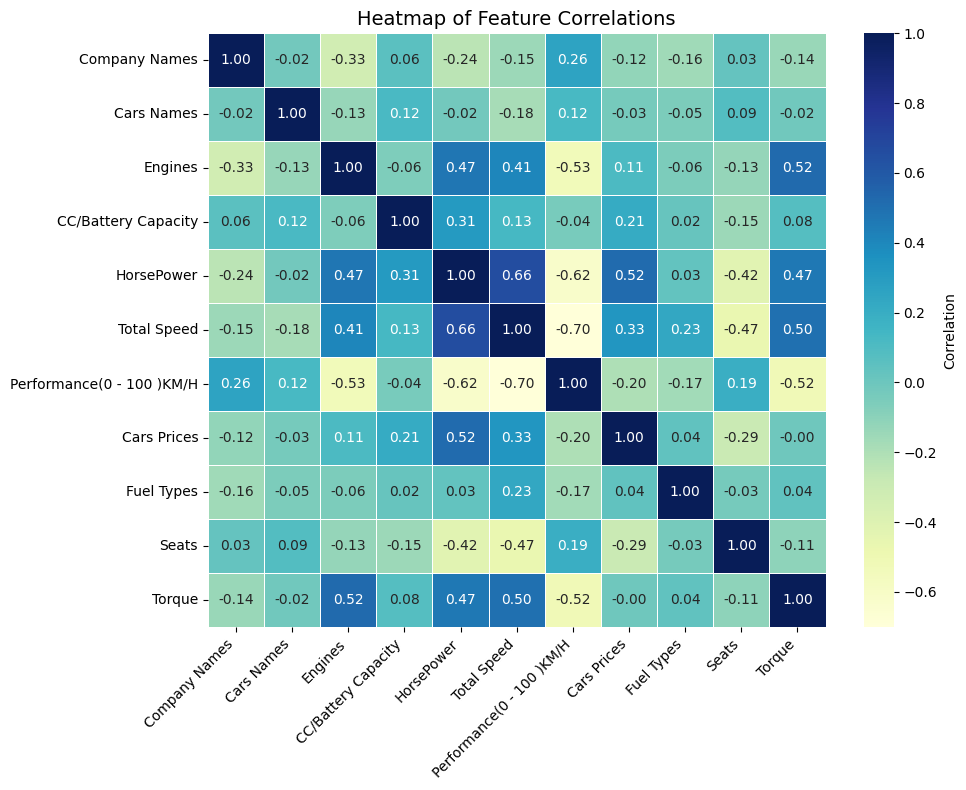

In [62]:
# سلول ۸ - مدل ۳ : پیش‌بینی Performance (0–100 km/h acceleration)
# و نمایش Heatmap از همبستگی ویژگی‌ها
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

# --- مدل‌سازی ---
# تعیین نام درست ستون هدف
perf_col = "Performance(0 - 100 )KM/H"

# ویژگی‌ها و هدف
X = df.drop(columns=[perf_col])
y = df[perf_col]

# تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# مدل جنگل تصادفی برای داده‌های غیربخطی
model_perf = RandomForestRegressor(random_state=42 )
model_perf.fit(X_train, y_train)
# Hyperparameter search for RandomForest to get a stronger base model
param_dist = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}

rnd_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=0
)
rnd_search.fit(X_train, y_train)

print("Best RF params:", rnd_search.best_params_)
print("Best RF CV MAE:", -rnd_search.best_score_)

# Train a fast gradient boosting candidate for comparison
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)

# Evaluate on the held-out test set and pick the better model
rf_best = rnd_search.best_estimator_
mae_rf = mean_absolute_error(y_test, rf_best.predict(X_test))
mae_hgb = mean_absolute_error(y_test, hgb.predict(X_test))

print("Test MAE - RF:", mae_rf, "HGB:", mae_hgb)

model_perf = rf_best if mae_rf <= mae_hgb else hgb
print("Selected model:", type(model_perf).__name__)
# پیش‌بینی و ارزیابی
pred_perf = model_perf.predict(X_test)
r2_perf = r2_score(y_test, pred_perf)
mae_perf = mean_absolute_error(y_test, pred_perf)

print(" Model: Car Performance Prediction (0–100 km/h)")
print("R2:", r2_perf)
print("MAE:", mae_perf)

# --- Heatmap of correlations ---
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Heatmap of Feature Correlations", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------
#  توضیحات نمودار Heatmap همبستگی (Feature Correlations):
# - این نمودار درصد هماهنگی (Correlation) بین تمام ستون‌های عددی دیتافریم را نمایش می‌دهد.
# - مقیاس رنگی از آبی تیره (همبستگی مثبت قوی ≈ +1) تا زرد روشن (همبستگی منفی قوی ≈ -1) است.
# - مقادیر بالا صفر تا نزدیک 1 یعنی دو ویژگی با هم نسبت مستقیم دارند
#   و افزایش یکی معمولاً با افزایش دیگری همراه است (مثلاً HorsePower و Torque ≈ 0.47).
# - مقادیر منفی نزدیک -1 یعنی رابطه‌ی معکوس شدید دارند
#   (مثلاً Performance(0-100 KM/H) و Total Speed ≈ -0.70 — یعنی با افزایش سرعت کل، زمان رسیدن به 100 کم می‌شود).
# - مقادیر نزدیک صفر یعنی تقریباً هیچ رابطه‌ی خطی بین آن دو ویژگی وجود ندارد.
# - این ماتریس برای انتخاب ویژگی‌های مهم جهت مدل‌سازی مفید است
#   چون می‌توان فهمید کدام ستون‌ها بیشترین تأثیر یا تداخل را با هدف پیش‌بینی دارند.
# -------------------------------------------------------------
